# DEFINE OUR CONSTANTS THROUGHT HTIS WORK

In [2]:
WHO_DAILY=15 #ug/m3 , who 2021 hour guideline

In [3]:
import pandas as pd
df=pd.read_csv('data/ACCRA_ALL_SITES_PM25_HOURLY.csv',low_memory=False)
#the date is a string let's parse into datetime
df['date']=pd.to_datetime(df['datetime_utc'],'coerce')
#set the date column as index




In [12]:
df.head()

,location_id,location_name,locality,sensor_id,datetime_utc,datetime_local,datetime_to_utc,datetime_to_local,pm25_value,latitude,longitude,provider,timezone,date
0,6313993,"+233, North Ridge",NaN,15998899,2026-04-19 20:00:00+00:00,2026-04-19T20:00:00Z,2026-04-19T21:00:00Z,2026-04-19T21:00:00Z,11.60,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-19 20:00:00+00:00
1,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 18:00:00+00:00,2026-04-21T18:00:00Z,2026-04-21T19:00:00Z,2026-04-21T19:00:00Z,5.17,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 18:00:00+00:00
2,6313993,"+233, North Ridge",NaN,15998899,2026-04-21 21:00:00+00:00,2026-04-21T21:00:00Z,2026-04-21T22:00:00Z,2026-04-21T22:00:00Z,15.20,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-21 21:00:00+00:00
3,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 00:00:00+00:00,2026-04-22T00:00:00Z,2026-04-22T01:00:00Z,2026-04-22T01:00:00Z,40.90,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 00:00:00+00:00
4,6313993,"+233, North Ridge",NaN,15998899,2026-04-22 01:00:00+00:00,2026-04-22T01:00:00Z,2026-04-22T02:00:00Z,2026-04-22T02:00:00Z,21.30,5.57375,-0.19544,Clarity,Africa/Accra,2026-04-22 01:00:00+00:00


In [4]:
#coerce pm25 values to numeric, errors will be set to NaN
df['pm25_value']=pd.to_numeric(df['pm25_value'],errors='coerce')
#let's check duplicate sensor readings, we will drop duplicates
df.duplicated(subset=['sensor_id','date']).sum()


np.int64(0)

Let's do a completeness check get a table considering the expected, the observed as well as the first and last readings, we'll use just one of th emost populated ones for our analyssis, you can use any for yours

In [5]:
summary=df.groupby(['sensor_id','location_name']).agg(first=('date','min'),last=('date','max'),observed=('pm25_value','count'),
                                              expected=('date',lambda x: (x.max()-x.min()).total_seconds()/3600+1)).sort_values('observed',ascending=False).head(10)

In [6]:
#let's see the 20 worse sites in terms of completeness of data, we will use the expected and observed columns to calculate completeness
summary['completness']=summary['observed']/summary['expected']*100
summary.sort_values('completness').head(20)

,,first,last,observed,expected,completness
sensor_id,location_name,,,,,
10826686,Amasaman,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,10803,15277.0,70.714145
6530278,Physics Department-UG-Accra/CAOA-UESD,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,11293,15277.0,73.921581
10330996,37 Lorry Station,2025-01-01 00:00:00+00:00,2026-09-29 12:00:00+00:00,11707,15277.0,76.631538
10331000,Kwashieman Presby Church,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12124,15278.0,79.355937
10331005,Lapaz Intersection,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12256,15278.0,80.219924
10330999,West Hills Mall,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12275,15278.0,80.344286
10330997,Ashaley Botwe School Junction,2025-01-01 00:00:00+00:00,2026-09-29 13:00:00+00:00,12276,15278.0,80.350831
7897442,Afri-SET,2025-01-01 00:00:00+00:00,2026-08-12 16:00:00+00:00,12248,14129.0,86.686956
7897459,Afri-SET,2025-01-01 00:00:00+00:00,2026-08-12 16:00:00+00:00,12258,14129.0,86.757732


We can't really asess all the sites but let's say lapaz intersection is the site of interest, let's pick it find out concerningduplicates, dsort it for time series and rebuild a gap free hourly analysis

In [63]:
#let's strip off string of th elocation names so that spaces don't cause issues when we filter by location name
df['location_name']=df['location_name'].str.strip()
#first let's sort, drop duplicate timesteps and index by date
lapaz=df[df['location_name']=='Lapaz Intersection'].sort_values('date').drop_duplicates(subset='date').set_index('date')

In [62]:
lapaz['pm25_value'].isna().sum()

np.int64(0)

We know that lapaz isn't complete, so we gotta time interpolate but we are careful to fill missing runs of 1-4 consecutive hours, longer gaps must stay nan

In [64]:
#let's find the gaps in the data
lapaz['gap']=lapaz.index.to_series().diff().dt.total_seconds()/3600
lapaz['gap'].value_counts().sort_index()
#i am specifically trying to fill gaps greater than one hour , that means to to give them a new pm25_value as a rolling mean
#first resample so that we insert gaps betweeen the dats, the orignal pm_25 has no na, so pandas doesn't know how to insert
lapaz_full=lapaz.resample('1H').asfreq()
#time-interpolate but only fill missing runs of 1–4 consecutive hours (longer gaps stay NaN — that is the course rule);
lapaz_full['pm25_value_filled']=lapaz_full['pm25_value'].interpolate(method='time',limit=4)
lapaz_full['pm25_value_filled'].isna().sum()

C:\Users\User\AppData\Local\Temp\ipykernel_163304\1874766288.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lapaz_full=lapaz.resample('1H').asfreq()


np.int64(475)

np.int64(475)

In [69]:
#print expected , hours filled and observed hours
#i can do expected hours as the difference between the last and first date in hours,observed hours as the count of non null pm25 values and filled hours as the count of non null pm25_value_filled values
lapaz_summary=pd.DataFrame({'expected_hours':(lapaz_full.index.max()-lapaz_full.index.min()).total_seconds()/3600,
                            'observed_hours':lapaz_full['pm25_value'].count(),
                            'filled_hours':lapaz_full['pm25_value_filled'].count()},index=[0])

In [70]:
lapaz_summary

,expected_hours,observed_hours,filled_hours
0,15277.0,12256,14803


In [71]:
#resample into daily means
lapaz_daily=lapaz_full['pm25_value_filled'].resample("D").mean()
#resample by monthly means
lapaz_monthly=lapaz_full['pm25_value_filled'].resample("M").mean()

C:\Users\User\AppData\Local\Temp\ipykernel_163304\523804517.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  lapaz_monthly=lapaz_full['pm25_value_filled'].resample("M").mean()


Now let's visualize the data, we've done all the preliminiary assessments

Text(0, 0.5, 'PM2.5 ($\\mu g/m^3$)')

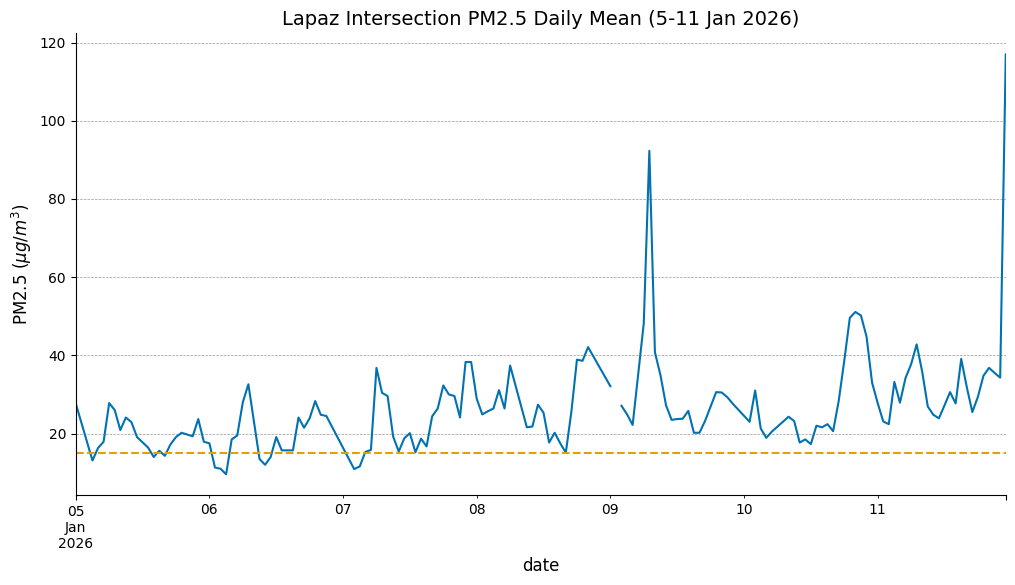

In [79]:
#let's define the colors GRAY, BLUE, ORANGE, GREEN = "#999999", "#0072B2", "#D55E00"
GREEN = "#009E73"
ORANGE = "#E69F00"
BLUE = "#0072B2"
GRAY = "#999999"

# no top/right spines, y-grid below the data) and reuse it for every figure. Put the style + plotting helpers in src/plots.py.
plot_style={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRAY,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.axisbelow": True,
    "axes.labelsize": 12,
    "axes.titlesize": 14,}
#let's select 5-11 janauary 20206 for lapaz to see harmatan
import matplotlib.pyplot as plt
plt.style.use(plot_style)
ax=lapaz_full['pm25_value_filled'].loc['2026-01-05':'2026-01-11'].plot(figsize=(12,6),color=BLUE)
ax.axhline(WHO_DAILY,color=ORANGE,linestyle='--',label='WHO Daily Guideline')
ax.set_title('Lapaz Intersection PM2.5 Daily Mean (5-11 Jan 2026)')
ax.set_ylabel('PM2.5 ($\mu g/m^3$)')



<Axes: xlabel='date'>

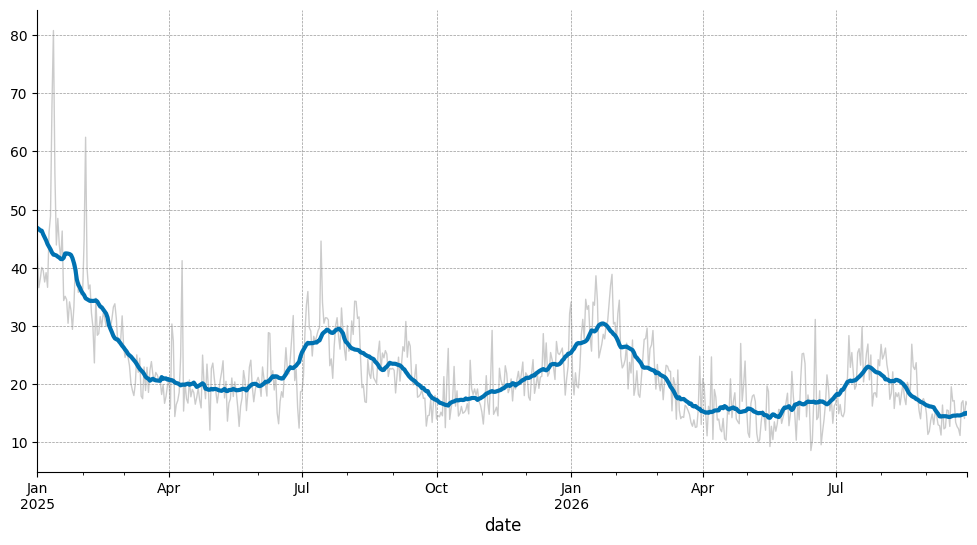

In [84]:
#let's see aggregating to daily means and plot a 30-day rolling mean with center true and min periods 15
lapaz_daily_rolling=lapaz_daily.rolling(30,center=True,min_periods=15).mean()
ax2=lapaz_daily.plot(figsize=(12,6),color=GRAY,linewidth=1,alpha=0.5)
lapaz_daily_rolling.plot(ax=ax2,color=BLUE,linewidth=3)

 Do everything we've done so far for but for tema port

In [91]:
tema_port=df[df['location_name']=='Tema Port'].sort_values('date').drop_duplicates(subset='date').set_index('date')


In [92]:
tema_port.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9986 entries, 2025-07-04 17:00:00+00:00 to 2026-09-29 12:00:00+00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location_id        9986 non-null   int64  
 1   location_name      9986 non-null   object 
 2   locality           0 non-null      object 
 3   sensor_id          9986 non-null   int64  
 4   datetime_utc       9986 non-null   object 
 5   datetime_local     9986 non-null   object 
 6   datetime_to_utc    9986 non-null   object 
 7   datetime_to_local  9986 non-null   object 
 8   pm25_value         9986 non-null   float64
 9   latitude           9986 non-null   float64
 10  longitude          9986 non-null   float64
 11  provider           9986 non-null   object 
 12  timezone           9986 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [95]:
#let's check for completeness and if necessary interpolate the data for tema port, we will use the same approach as lapaz intersection
tema_port.index.to_series().diff().dt.total_seconds().div(3600).value_counts()

date
1.0      9899
2.0        29
4.0        14
3.0         9
5.0         7
6.0         6
9.0         5
7.0         3
12.0        2
8.0         2
19.0        2
39.0        1
20.0        1
274.0       1
169.0       1
10.0        1
15.0        1
61.0        1
Name: count, dtype: int64

In [96]:
#oksy we've got only few gaps, let's interpolate the data for tema port, we will use the same approach as lapaz intersection
tema_port_full=tema_port.resample('1H').asfreq()
tema_port_full['pm25_value_filled']=tema_port_full['pm25_value'].interpolate(method='time',limit=4)

C:\Users\User\AppData\Local\Temp\ipykernel_163304\1421811566.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tema_port_full=tema_port.resample('1H').asfreq()


C:\Users\User\AppData\Local\Temp\ipykernel_163304\2442592963.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tema_port_full_monnthly=tema_port_full['pm25_value_filled'].resample("M").mean()
C:\Users\User\AppData\Local\Temp\ipykernel_163304\2442592963.py:6: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  tpgrah.plot(tema_port_full_daily_rolling,color=BLUE,linewidth=3)


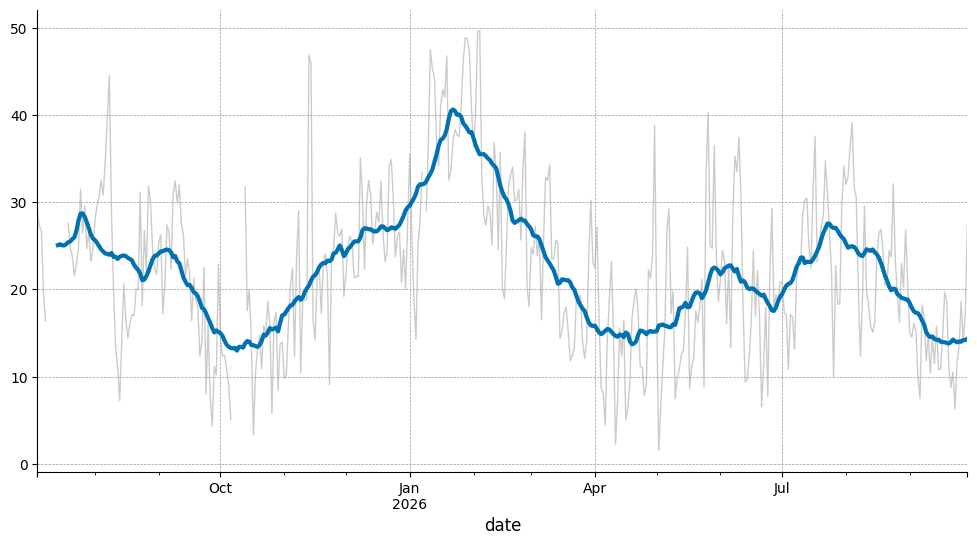

In [97]:
#let's do the same plots for tema
tema_port_full_daily=tema_port_full['pm25_value_filled'].resample("D").mean()
tema_port_full_monnthly=tema_port_full['pm25_value_filled'].resample("M").mean()
tpgrah=tema_port_full_daily.plot(figsize=(12,6),color=GRAY,linewidth=1,alpha=0.5)
tema_port_full_daily_rolling=tema_port_full_daily.rolling(30,center=True,min_periods=15).mean()
tpgrah.plot(tema_port_full_daily_rolling,color=BLUE,linewidth=3)

# DIRUNAL PATTERNS

In [98]:
lapaz.columns

Index(['location_id', 'location_name', 'locality', 'sensor_id', 'datetime_utc',
       'datetime_local', 'datetime_to_utc', 'datetime_to_local', 'pm25_value',
       'latitude', 'longitude', 'provider', 'timezone', 'gap'],
      dtype='object')

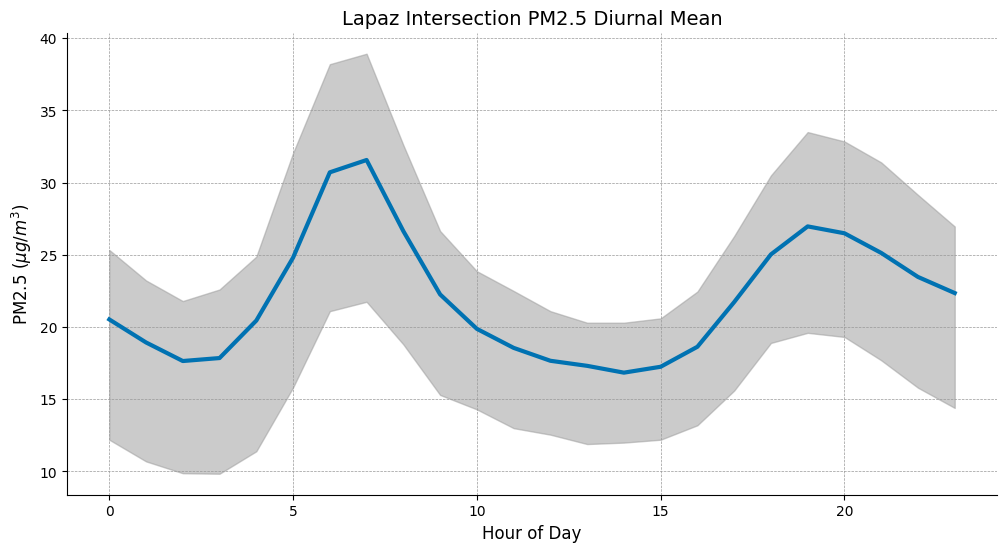

In [105]:
#FOR THIS LET'S TRY USING THE AFRICA/ACCRA LOCAL TIME , AND SET IT AS INDEX FOR LAPAZ
lapaz_accra=lapaz_full.copy()
lapaz_accra['date']=lapaz_accra.index.tz_convert('Africa/Accra')
#let's compute the dirunal mean,
diurnal_hourly=lapaz_accra.groupby(lapaz_accra.index.hour)['pm25_value_filled'].mean()
diplot=diurnal_hourly.plot(figsize=(12,6),color=BLUE,linewidth=3)
diplot.set_title('Lapaz Intersection PM2.5 Diurnal Mean')
diplot.set_xlabel('Hour of Day')
diplot.set_ylabel('PM2.5 ($\mu g/m^3$)')
#lets add iqr bands to the plot, we will compute the 25th and 75th percentiles for each hour of the day
diurnal_hourly_iqr=lapaz_accra.groupby(lapaz_accra.index.hour)['pm25_value_filled'].quantile([0.25,0.75]).unstack()
diplot.fill_between(diurnal_hourly_iqr.index,diurnal_hourly_iqr[0.25],diurnal_hourly_iqr[0.75],color=GRAY,alpha=0.5)


